# Reference
- https://github.com/MyoHub/myosuite/blob/main/tutorials/6_Inverse_Dynamics.ipynb

# Common Libraries

In [1]:
import os, shutil, osqp
import numpy as np
import pandas as pd
from tqdm import tqdm
import mediapy as media
import scipy.sparse as spa
import matplotlib.pyplot as plt

if shutil.which('nvidia-smi') is not None:
    os.environ['MUJOCO_GL'] = 'egl'
import mujoco
from myosuite.simhive.myo_sim.test_sims import TestSims as loader

MyoSuite:> Registering Myo Envs


/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spe

In [2]:
def solve_qp(P, q, lb, ub, x0):
    """
    Solve a quadratic program.
    """
    P = spa.csc_matrix(P)
    A = spa.csc_matrix(spa.eye(q.shape[0]))
    m = osqp.OSQP()
    m.setup(P=P, q=q, A=A, l=lb, u=ub, verbose=False)
    m.warm_start(x=x0)
    res = m.solve()
    return res.x

def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

# Load data

In this tutorial a target trajectory will be replicated by MyoHand using MuJoCo inverse dynamics, i.e., given a sequence of joint angles qpos, a sequence of control ctrl will be generated.

In [3]:
dir_path = "/home/seojin/StudyForMyoSuite/Data"
traj_path = os.path.join(dir_path, "6_trajectory.csv")
traj_df = pd.read_csv(traj_path)

times = traj_df["time"]
qpos_traj_array = traj_df.drop("time", axis = 1).values

n_times, n_joints = qpos_traj_array.shape

# Computation of the generalized force

The computation of ctrl is dependent on qfrc, which can be obtained using inverse dynamics. Disabling the constraint solver during this phase avoids simulation divergence.

The effectiveness of the computed qfrc can be tested by applying it directly as shown below.

# Initialize model and data

In [4]:
model = loader.get_sim(None, 'hand/myohand.xml')
joint_names = [model.joint(i).name for i in range(model.nq)]
data = mujoco.MjData(model)

# Calculate moment of each joint and simulate joint angle by applying the moment

In [5]:
qfrcs = np.zeros((n_times, n_joints))
qpos_simulated_traj_array = np.zeros((n_times, n_joints))
for time_i in tqdm(range(n_times)):
    target_qpos = qpos_traj_array[time_i]
    qforces = get_qfrc(model, data, target_qpos)
    qfrcs[time_i] = qforces
    data.qfrc_applied = qforces
    mujoco.mj_step(model, data)
    qpos_simulated_traj_array[time_i] = data.qpos

100%|██████████| 4751/4751 [00:03<00:00, 1449.52it/s]


# Verification

In [6]:
error = (qpos_traj_array - qpos_simulated_traj_array).mean(axis = 0)
print(f'error max (rad): {error.max()}')

error max (rad): 0.0007212988736761737


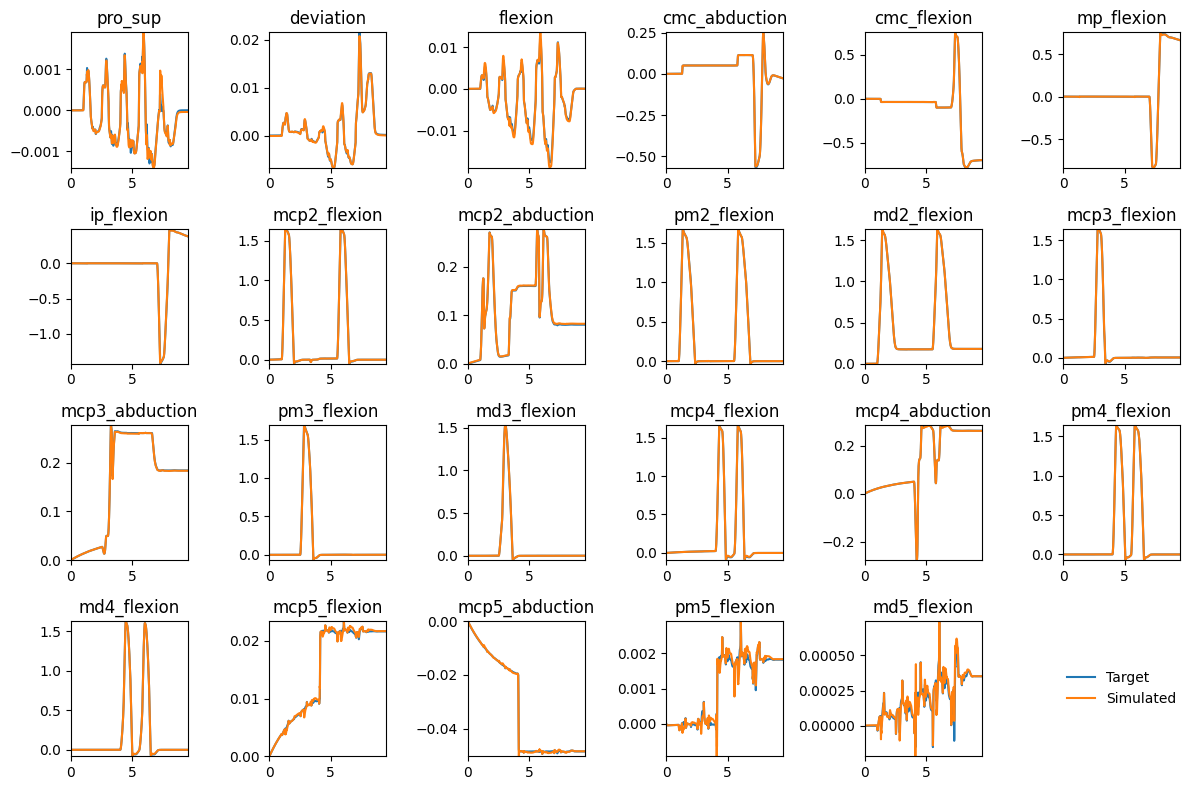

In [7]:
fig, axs = plt.subplots(4, 6, figsize=(12, 8))
axs = axs.flatten()

for joint_i in range(len(joint_names)):
    joint_name = joint_names[joint_i]
    axis = axs[joint_i]
    axis.plot(times, qpos_traj_array[:, joint_i])
    axis.plot(times, qpos_simulated_traj_array[:, joint_i])

    min_val = min(np.min(qpos_traj_array[:, joint_i]), np.min(qpos_simulated_traj_array[:, joint_i]))
    max_val = max(np.max(qpos_traj_array[:, joint_i]), np.max(qpos_simulated_traj_array[:, joint_i]))
    
    axis.set_xlim([times.min(), times.max()])
    axis.set_ylim([min_val, max_val])
    axis.set_title(joint_name)

legend_ax = axs[len(joint_names)] # create legend in the 24th subplot area
legend_ax.axis('off')
line1, = legend_ax.plot([], [], label='Target')
line2, = legend_ax.plot([], [], label='Simulated')
legend_ax.legend(handles = [line1, line2],
                 loc = 'center',
                 frameon = False)
plt.tight_layout()

The difference between the reference trajectory and the achieved one is practically zero. It was observed, however, that by scaling the computed qfrc it is possible to achieve an equally valid replication with a larger but still negligible error. Below are examples of the result that can be obtained by dividing the computed qfrc by 10, 100, and 1000. Among the three, using a scaler up to 100 allows good replication, while 1000 does not. The advantage in using lower qfrc is the easier solution of the optimization problem during the computation of ctrl in the next phase.

In [8]:
all_qfrc_scaler = [1, 10, 100, 1000]
n_simulation = len(all_qfrc_scaler)
qpos_simulated_traj_array = np.zeros((n_times, n_joints, n_simulation))

reference_i = 0
for scalar_i, scaler in enumerate(all_qfrc_scaler):
    if scalar_i == 0:
        qpos_simulated_traj_array[:, :, reference_i] = qpos_traj_array
    else:
        data = mujoco.MjData(model)
        for time_i in tqdm(range(n_times)):
            target_qpos = qpos_traj_array[time_i]
            qfrc = get_qfrc(model, data, target_qpos)
            data.qfrc_applied = qfrc / scaler
            mujoco.mj_step(model, data)
            qpos_simulated_traj_array[time_i, :, scalar_i] = data.qpos
        error = ((qpos_simulated_traj_array[:,:,scalar_i] - qpos_simulated_traj_array[:,:, reference_i])**2).mean(axis=0)
        print(f'qfrc scaler: {scaler} - error max (rad): {error.max()}')

100%|██████████| 4751/4751 [00:03<00:00, 1446.74it/s]


qfrc scaler: 10 - error max (rad): 0.00023935198753077865


100%|██████████| 4751/4751 [00:03<00:00, 1429.54it/s]


qfrc scaler: 100 - error max (rad): 0.013233213107663228


100%|██████████| 4751/4751 [00:03<00:00, 1430.78it/s]

qfrc scaler: 1000 - error max (rad): 0.13942911086810011


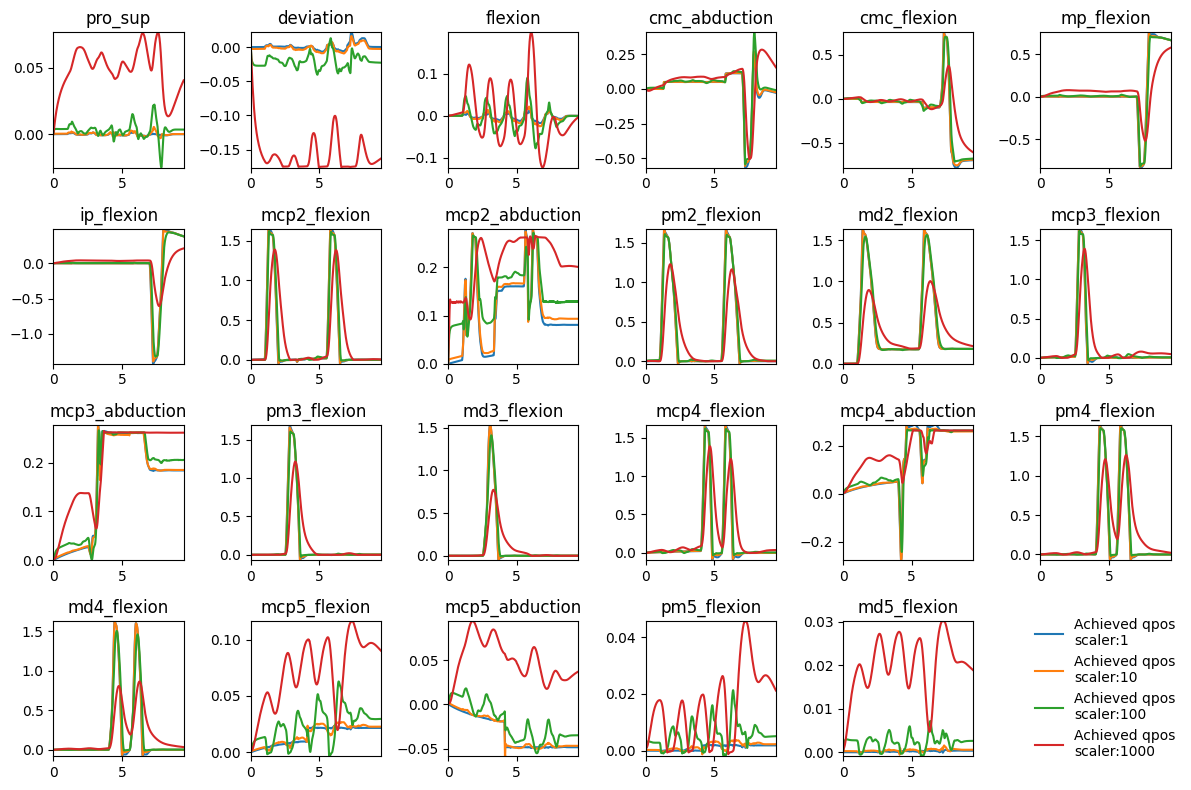

In [9]:
fig, axs = plt.subplots(4, 6, figsize=(12, 8))
axs = axs.flatten()

for joint_i in range(len(joint_names)):
    joint_name = joint_names[joint_i]
    axis = axs[joint_i]

    min_val = min(np.min(qpos_simulated_traj_array[:, joint_i, :]), np.min(qpos_simulated_traj_array[:, joint_i, :]))
    max_val = max(np.max(qpos_simulated_traj_array[:, joint_i, :]), np.max(qpos_simulated_traj_array[:, joint_i, :]))

    for scalar_i, scaler in enumerate(all_qfrc_scaler):
        data = qpos_simulated_traj_array[:, joint_i, scalar_i]
        axis.plot(times, data)
        axis.set_xlim([times.min(), times.max()])
        axis.set_ylim([min_val, max_val])
        axis.set_title(joint_name)

labels = [f"Achieved qpos\nscaler:{scaler}" for scaler in all_qfrc_scaler]
legend_ax = axs[len(joint_names)]
legend_ax.axis('off')
legends = [legend_ax.plot([], [], label = label)[0] for label in labels]
legend_ax.legend(handles = legends,
                 loc = 'center',
                 frameon = False)
plt.tight_layout()

# Computation of the control

The following describes how the get_ctrl function works. The equation to solve for ctrl, accordingly to muscle actuators dynamics (https://mujoco.readthedocs.io/en/latest/modeling.html#muscles), is:

$$ AM \cdot \left( gain \odot \left( act + timestep \cdot \frac{ctrl - act}{\tau} \right) + bias \right) - qfrc = 0 \quad (1) $$

where $AM$ stands for the muscle actuator moment arms, is the Hadamard product and

$$\tau = \tau_{D} + (\tau_{A} - \tau_{D}) \cdot sigmoid \left( \frac{ctrl - act}{tausmooth} + 0.5 \right)$$

To find a solution quickly, it is better to reformulate the equation and solve a quadratic program (QP), i.e.:

$$\min_{x} \frac{1}{2}x^{T}Px + q^{T}x \quad s.t. \quad lb \leq x \leq ub \quad (2)$$

The major obstacle to this formulation is the sigmoid in the calculation of 
$\tau$. MuJoCo implements the sigmoid using the polynomial $6x^5 - 15x^4 + 10x^3$ clipped between 0 and 1. To solve the QP, the sigmoid is approximated here with $1.875x - 0.4375$ and, to limit its range for a good approximation, tausmooth is set to 5. The target equation can then be rewritten as:
 
$$AM \cdot \left( gain \odot \left( act + timestep \cdot \frac{ctrl - act}{(ctrl - act) \cdot \tau_1 + \tau_2} \right) + bias \right) - qfrc = 0 \quad (3)$$

where

$$\tau_1 = \frac{\tau_A - \tau_D}{tausmooth} \cdot 1.875, \quad \tau_2 = (\tau_A + \tau_D) \cdot 0.5$$

and consequently reformulated as:

$$ AM \cdot x + k = 0 \quad (4) $$

where

$$x = \left( timestep \cdot gain \odot \frac{ctrl - act}{(ctrl - act) \cdot \tau_1 + \tau_2} \right), \quad k = AM \cdot (gain \odot act) + AM \cdot bias - qfrc$$

Referring to equation (2) then:

$$ P = 2 \cdot AM^{T} \cdot AM $$
$$ q = 2 \cdot AM^{T} \cdot k $$

$$lb = timestep \cdot gain \odot \frac{1 - act}{(1 - act) \cdot \tau_1 + \tau_2} \quad (7)$$

$$ub = timestep \cdot gain \odot \frac{-act}{-act \cdot \tau_1 + \tau_2} \quad (8)$$

After solving the QP for x, ctrl is then calculated as:

$$ctrl = act + \frac{x \cdot \tau_2}{timestep \cdot gain - x \cdot \tau_1} \quad (9)$$

In [10]:
def get_ctrl(model, data, target_qpos, qfrc, qfrc_scaler, qvel_scaler):
    """
    Compute the control needed to reach the target position in the next mujoco step.
    qfrc: generalized force resulting from inverse dynamics.
    """
    act = data.act
    ctrl0 = data.ctrl
    ts = model.opt.timestep
    tA = model.actuator_dynprm[:,0] * (0.5 + 1.5 * act)
    tD = model.actuator_dynprm[:,1] / (0.5 + 1.5 * act)
    tausmooth = model.actuator_dynprm[:,2]
    t1 = (tA - tD) * 1.875 / tausmooth
    t2 = (tA + tD) * 0.5
    # ---- gain, bias, and moment computation
    data_copy = mujoco.MjData(model)
    data_copy.qpos = target_qpos
    data_copy.qvel = ((target_qpos - data.qpos) / model.opt.timestep) / qvel_scaler
    mujoco.mj_step1(model, data_copy) # gain, bias, and moment depend on qpos and qvel
    gain = np.zeros(model.nu)
    bias = np.zeros(model.nu)
    for idx_actuator in range(model.nu):
        length = data_copy.actuator_length[idx_actuator]
        lengthrange = model.actuator_lengthrange[idx_actuator]
        velocity = data_copy.actuator_velocity[idx_actuator]
        acc0 = model.actuator_acc0[idx_actuator]
        prmb = model.actuator_biasprm[idx_actuator,:9]
        prmg = model.actuator_gainprm[idx_actuator,:9]
        bias[idx_actuator] = mujoco.mju_muscleBias(length, lengthrange, acc0, prmb)
        gain[idx_actuator] = min(-1, mujoco.mju_muscleGain(length, velocity, lengthrange, acc0, prmg))

    AM = np.zeros((model.nu, model.nv))
    mujoco.mju_sparse2dense(AM,
                            data.actuator_moment.reshape(-1),
                            data.moment_rownnz,
                            data.moment_rowadr,
                            data.moment_colind.reshape(-1))
    AM = AM.T
    # ---- ctrl computation
    P = 2 * AM.T @ AM
    k = AM @ (gain * act) + AM @ bias - (qfrc / qfrc_scaler)
    q = 2 * k @ AM
    lb = gain * (1 - act) * ts / (t2 + t1 * (1 - act))
    ub = - gain * act * ts / (t2 - t1 * act)
    x0 = (gain * (ctrl0 - act) * ts) / ((ctrl0 - act) * t1 + t2)
    x = solve_qp(P, q, lb, ub, x0)
    ctrl = act + x * t2 / (gain * ts - x * t1)
    return np.clip(ctrl,0,1)

The ctrl sequence to be applied to MyoHand in order to replicate the reference trajectory can thus be achieved.

In [11]:
hand_model = loader.get_sim(None, 'hand/myohand.xml')
tausmooth = 5
hand_model.actuator_dynprm[:,2] = tausmooth
hand_data = mujoco.MjData(hand_model)
all_ctrl = np.zeros((n_times, hand_model.nu))
for time_i in tqdm(range(n_times)):
    target_qpos = qpos_traj_array[time_i]
    qfrc = get_qfrc(hand_model, hand_data, target_qpos)
    ctrl = get_ctrl(hand_model, hand_data, target_qpos, qfrc, 100, 5)
    hand_data.ctrl = ctrl
    mujoco.mj_step(hand_model, hand_data)
    all_ctrl[time_i, :] = ctrl

100%|██████████| 4751/4751 [00:12<00:00, 367.59it/s]


The use of a new scaler is also included in this phase. Indeed, it was observed that by reducing the velocity set for gain computation, the obtained ctrl is more stable. Below is an example to compare the results using a scaler equal to 5.

In [12]:
all_qvel_scaler = [1, 5]
qpos_eval = np.zeros((n_times, n_joints, len(all_qvel_scaler)))
ctrl_eval = np.zeros((n_times, hand_model.nu, len(all_qvel_scaler)))
for scaler_i, scaler in enumerate(all_qvel_scaler):
    hand_data = mujoco.MjData(hand_model)
    for time_i in tqdm(range(n_times)):
        target_qpos = qpos_traj_array[time_i]
        qfrc = get_qfrc(hand_model, hand_data, target_qpos)
        ctrl = get_ctrl(hand_model, hand_data, target_qpos, qfrc, 100, scaler)
        hand_data.ctrl = ctrl
        mujoco.mj_step(hand_model, hand_data)
        qpos_eval[time_i, :, scaler_i] = hand_data.qpos
        ctrl_eval[time_i, :, scaler_i] = ctrl
    error = ((qpos_eval[:, :,scaler_i] - qpos_traj_array)**2).mean(axis=0)
    print(f'qvel scaler: {scaler} - error max (rad): {error.max()}')

100%|██████████| 4751/4751 [00:12<00:00, 370.24it/s]


qvel scaler: 1 - error max (rad): 0.012068262782797134


100%|██████████| 4751/4751 [00:12<00:00, 368.80it/s]

qvel scaler: 5 - error max (rad): 0.013749303688869462


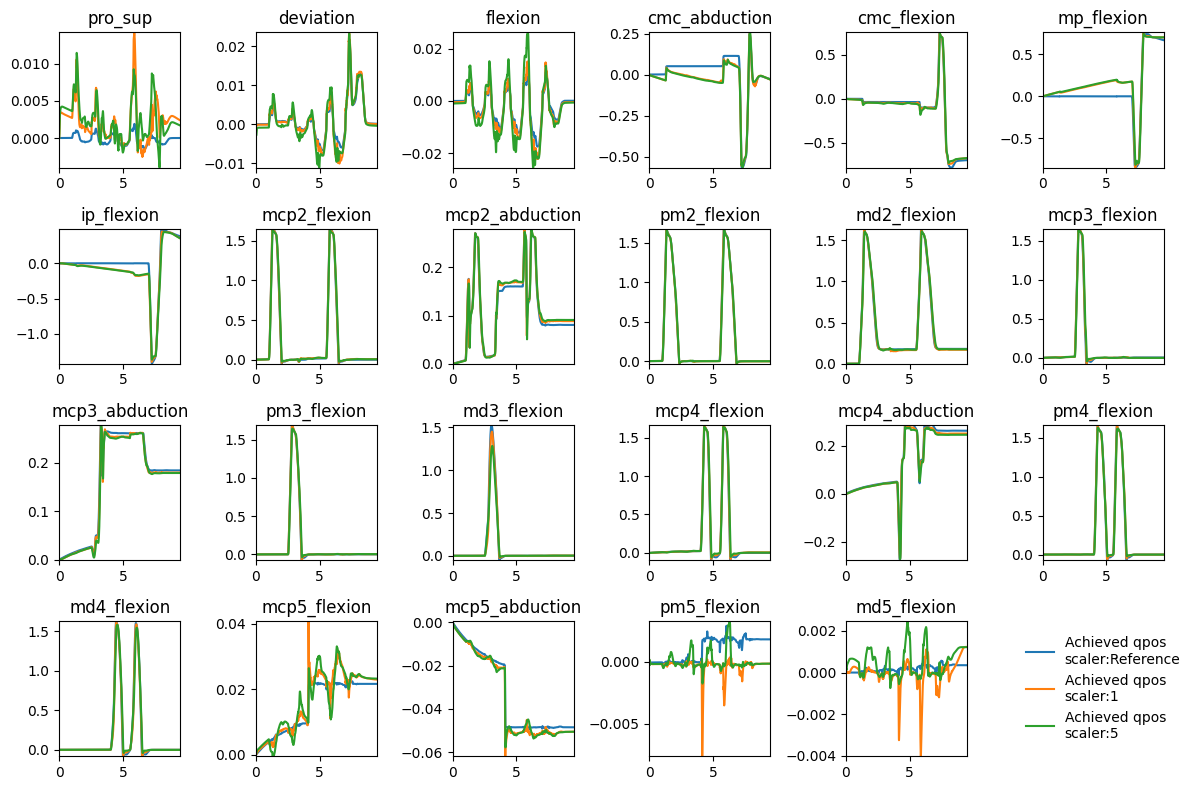

In [13]:
fig, axs = plt.subplots(4, 6, figsize=(12, 8))
axs = axs.flatten()

for joint_i in range(len(joint_names)):
    joint_name = joint_names[joint_i]
    axis = axs[joint_i]

    min_val = min(np.min(qpos_traj_array[:, joint_i]), np.min(qpos_eval[:, joint_i, :]))
    max_val = max(np.max(qpos_traj_array[:, joint_i]), np.max(qpos_eval[:, joint_i, :]))

    axis.plot(times, qpos_traj_array[:, joint_i])
    
    axis.set_xlim([times.min(), times.max()])
    axis.set_ylim([min_val, max_val])
    axis.set_title(joint_name)
    
    for scalar_i, scaler in enumerate(all_qvel_scaler):
        data = qpos_eval[:, joint_i, scalar_i]
        axis.plot(times, data)

labels = [f"Achieved qpos\nscaler:{scaler}" for scaler in ["Reference"] + all_qvel_scaler]
legend_ax = axs[len(joint_names)]
legend_ax.axis('off')
legends = [legend_ax.plot([], [], label = label)[0] for label in labels]
legend_ax.legend(handles = legends,
                 loc = 'center',
                 frameon = False)
plt.tight_layout()

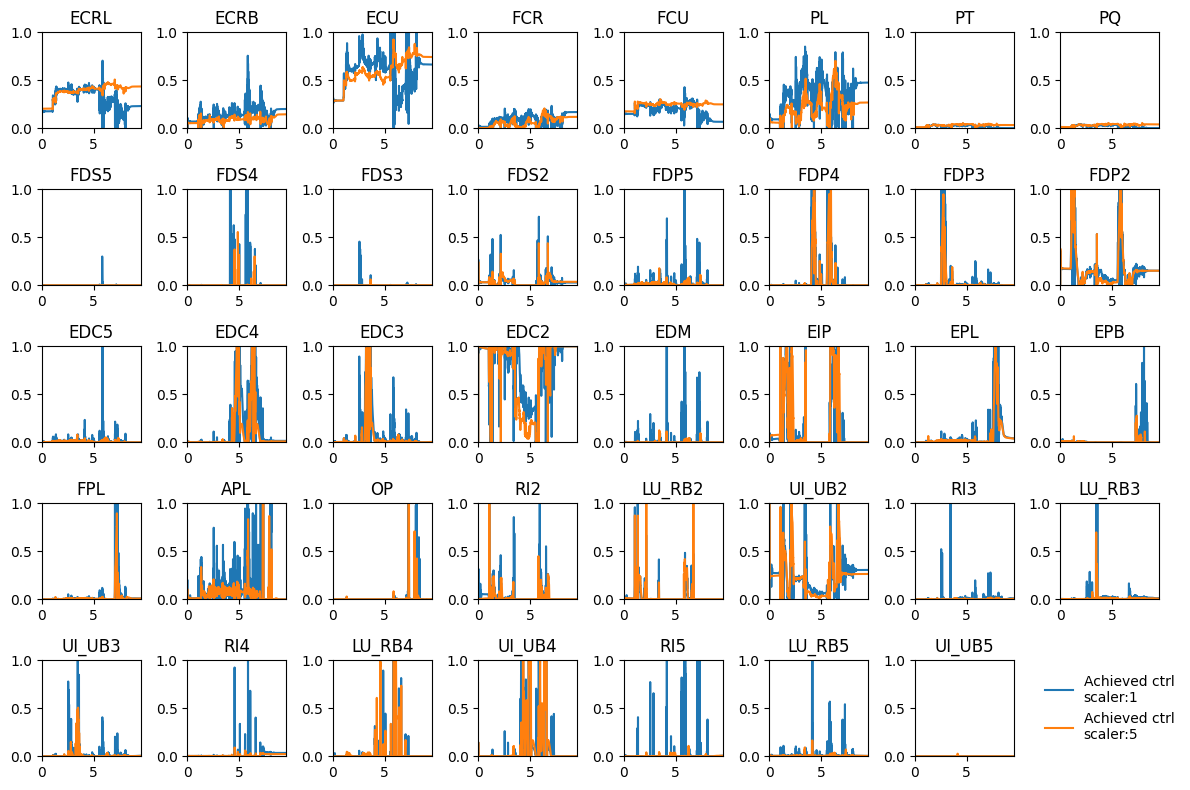

In [15]:
muscle_names = [hand_model.actuator(i).name for i in range(hand_model.nu)]
fig, axs = plt.subplots(5, 8, figsize=(12, 8))
axs = axs.flatten()

for muscle_i in range(len(muscle_names)):
    muscle_name = muscle_names[muscle_i]
    axis = axs[muscle_i]

    min_val = 0 # min(np.min(ctrl_eval[:, muscle_i]), np.min(ctrl_eval[:, muscle_i, :]))
    max_val = 1 # max(np.max(ctrl_eval[:, muscle_i]), np.max(ctrl_eval[:, muscle_i, :]))
    axis.set_title(muscle_name)
    axis.set_xlim([times.min(), times.max()])
    axis.set_ylim([min_val, max_val])
    
    for scalar_i, scaler in enumerate(all_qvel_scaler):
        axis.plot(times, ctrl_eval[:, muscle_i, scalar_i])
        
labels = [f"Achieved ctrl\nscaler:{scaler}" for scaler in all_qvel_scaler]
legend_ax = axs[-1]
legend_ax.axis('off')
legends = [legend_ax.plot([], [], label = label)[0] for label in labels]
legend_ax.legend(handles = legends,
                 loc = 'center',
                 frameon = False)
plt.tight_layout()

# Results

The trajectory achievable by applying the ctrl sequence resulting from the previous block is compared below with the reference trajectory.

In [15]:
# ---- initializations
hand_model_ref = loader.get_sim(None, 'hand/myohand.xml')
hand_model_ref.actuator_dynprm[:,2] = tausmooth
data_ref = mujoco.MjData(hand_model_ref) # data for reference trajectory
model_test = loader.get_sim(None, 'hand/myohand.xml')
model_test.actuator_dynprm[:,2] = tausmooth
data_test = mujoco.MjData(model_test) # test data for achieved trajectory
# ---- camera settings
camera = mujoco.MjvCamera()
camera.azimuth = 166.553
camera.distance = 1.178
camera.elevation = -36.793
camera.lookat = np.array([-0.93762553, -0.34088276, 0.85067529])
options_ref = mujoco.MjvOption()
options_ref.flags[:] = 0
options_ref.geomgroup[1:] = 0
options_test = mujoco.MjvOption()
options_test.flags[:] = 0
options_test.flags[4] = 1 # actuator ON
options_test.geomgroup[1:] = 0
renderer_ref = mujoco.Renderer(hand_model_ref)
renderer_ref.scene.flags[:] = 0
renderer_test = mujoco.Renderer(model_test)
renderer_test.scene.flags[:] = 0
# ---- generation loop
frames = []
for time_i in tqdm(range(n_times)):
    # -- reference trajectory
    data_ref.qpos = qpos_traj_array[time_i]
    mujoco.mj_step1(hand_model_ref, data_ref)
    # -- achieved trajectory
    data_test.ctrl = all_ctrl[time_i]
    mujoco.mj_step(model_test, data_test)
    # -- frames generation
    if not time_i % round(0.3/(model_test.opt.timestep*25)):
        renderer_ref.update_scene(data_ref, camera=camera, scene_option=options_ref)
        frame_ref = renderer_ref.render()
        renderer_test.update_scene(data_test, camera=camera, scene_option=options_test)
        frame_test = renderer_test.render()
        frame_merged = np.append(frame_ref, frame_test, axis=1)
        frames.append(frame_merged)

100%|██████████| 4751/4751 [00:01<00:00, 2465.73it/s]


In [16]:
# show video
media.show_video(frames, fps=30)

This browser does not support the video tag.
